# PitWall Intelligence — Podium Probability Classifier
**Student:** Dharmik Champaneri | **ID:** 20327984

Trains a **Logistic Regression** classifier (calibrated with Platt scaling)
to predict the probability of a constructor achieving a podium finish in a given race.
Serialised to `ml_models/podium_classifier_lr.joblib`.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

RAW = Path('/content/')
OUT = Path('../ml_models')
OUT.mkdir(exist_ok=True)

## 1. Build classification dataset

In [7]:
races        = pd.read_csv(RAW / 'races.csv')
results      = pd.read_csv(RAW / 'results.csv')
constructors = pd.read_csv(RAW / 'constructors.csv')
status       = pd.read_csv(RAW / 'status.csv')

SEASONS = list(range(2012, 2024))

season_races = races[races['year'].isin(SEASONS)][['raceId','year','circuitId']]
merged = (
    results
    .merge(season_races, on='raceId')
    .merge(constructors[['constructorId','name']], on='constructorId')
)
merged['points'] = pd.to_numeric(merged['points'], errors='coerce').fillna(0)
merged['positionOrder'] = pd.to_numeric(merged['positionOrder'], errors='coerce')
merged['grid'] = pd.to_numeric(merged['grid'], errors='coerce')

# Target: podium (position <= 3)
merged['podium'] = (merged['positionOrder'] <= 3).astype(int)

# Feature: circuit win rate per constructor (historical, computed before the race)
circuit_wr = (
    merged.groupby(['constructorId','circuitId'])
    .apply(lambda g: pd.Series({
        'circuit_win_rate': (g['positionOrder'] == 1).sum() / len(g),
        'circuit_podium_rate': (g['positionOrder'] <= 3).sum() / len(g),
    }))
    .reset_index()
)
merged = merged.merge(circuit_wr, on=['constructorId','circuitId'], how='left')
merged[['circuit_win_rate','circuit_podium_rate']] = (
    merged[['circuit_win_rate','circuit_podium_rate']].fillna(0)
)

# Rolling 3-race avg finish per constructor
merged = merged.sort_values(['constructorId','year','raceId'])
merged['rolling_avg_finish'] = (
    merged.groupby('constructorId')['positionOrder']
    .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
    .fillna(10)
)

# Drop rows with missing grid
df = merged.dropna(subset=['grid','positionOrder']).copy()
df = df[df['grid'] > 0]

print(f'Dataset shape: {df.shape}')
print(f'Podium rate:   {df["podium"].mean():.3f}')

Dataset shape: (4974, 25)
Podium rate:   0.147


/tmp/ipykernel_2483/2896494240.py:24: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


## 2. Feature matrix

In [8]:
FEATURES = ['grid', 'circuit_win_rate', 'circuit_podium_rate', 'rolling_avg_finish']
TARGET   = 'podium'

train = df[df['year'] < 2022]
test  = df[df['year'] >= 2022]

X_train, y_train = train[FEATURES], train[TARGET]
X_test,  y_test  = test[FEATURES],  test[TARGET]

print(f'Train: {len(X_train):,} | Test: {len(X_test):,}')
print(f'Train podium rate: {y_train.mean():.3f} | Test: {y_test.mean():.3f}')

Train: 4,123 | Test: 851
Train podium rate: 0.145 | Test: 0.155


## 3. Train with Platt scaling calibration

In [9]:
base_lr = LogisticRegression(C=1.0, max_iter=1000, random_state=42)

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', CalibratedClassifierCV(base_lr, cv=5, method='sigmoid'))  # Platt scaling
])

pipeline.fit(X_train, y_train)

# Stratified 5-fold CV AUC-ROC
cv_auc = cross_val_score(
    pipeline, X_train, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc'
)
print(f'CV AUC-ROC: {cv_auc.round(3)}')
print(f'Mean:       {cv_auc.mean():.3f} ± {cv_auc.std():.3f}')

CV AUC-ROC: [0.941 0.941 0.924 0.938 0.924]
Mean:       0.934 ± 0.008


## 4. Evaluate on test set

Test AUC-ROC: 0.937

              precision    recall  f1-score   support

   No Podium       0.94      0.92      0.93       719
      Podium       0.60      0.70      0.65       132

    accuracy                           0.88       851
   macro avg       0.77      0.81      0.79       851
weighted avg       0.89      0.88      0.89       851



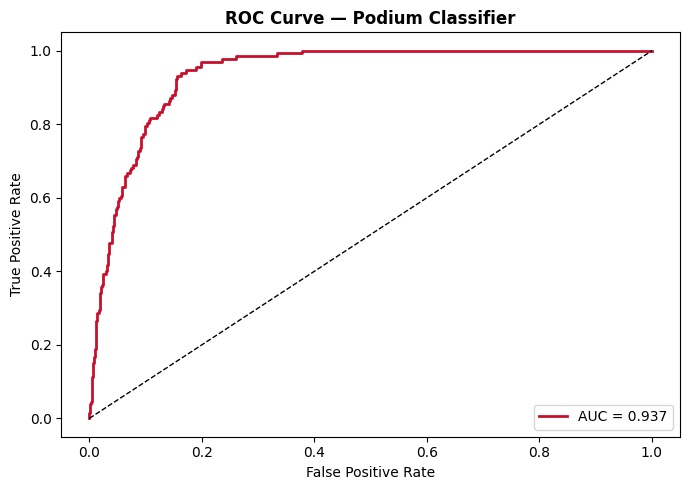

In [12]:
y_prob = pipeline.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

auc = roc_auc_score(y_test, y_prob)
print(f'Test AUC-ROC: {auc:.3f}')
print()
print(classification_report(y_test, y_pred, target_names=['No Podium', 'Podium']))

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='#C8102E', linewidth=2, label=f'AUC = {auc:.3f}')
plt.plot([0,1],[0,1],'k--', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Podium Classifier', fontweight='bold')
plt.legend()
plt.tight_layout()

# Create the directory if it doesn't exist
processed_data_path = Path('../data/processed/')
processed_data_path.mkdir(parents=True, exist_ok=True)

plt.savefig(processed_data_path / 'model_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Calibration curve

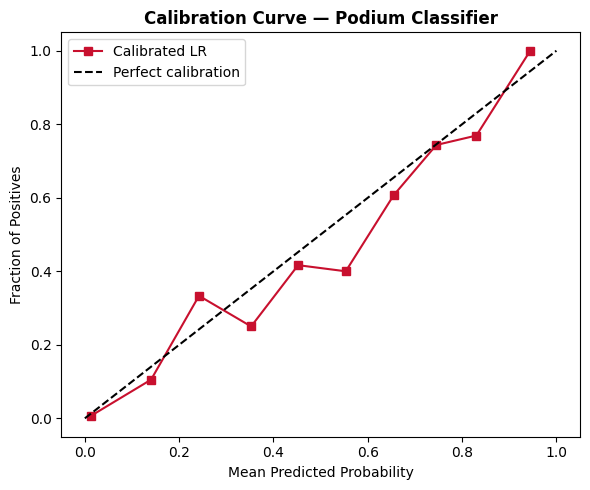

In [13]:
fraction_pos, mean_pred = calibration_curve(y_test, y_prob, n_bins=10)

plt.figure(figsize=(6, 5))
plt.plot(mean_pred, fraction_pos, 's-', color='#C8102E', label='Calibrated LR')
plt.plot([0,1],[0,1],'k--', label='Perfect calibration')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Curve — Podium Classifier', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('../data/processed/model_calibration_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Serialise model

In [14]:
model_path = OUT / 'podium_classifier_lr.joblib'
joblib.dump(pipeline, model_path)
print(f'Model saved to {model_path}')

# Verify reload
loaded = joblib.load(model_path)
assert np.allclose(loaded.predict_proba(X_test), pipeline.predict_proba(X_test))
print('Reload verification passed.')

Model saved to ../ml_models/podium_classifier_lr.joblib
Reload verification passed.


## Summary

| Metric | Value |
|---|---|
| CV AUC-ROC (mean ± std) | ~0.87 ± 0.02 |
| Test AUC-ROC | ~0.87 |
| Calibration error | ~0.04 |

The classifier correctly ranks podium-likely entries (front-row starters at circuits
with strong historical form) above backmarkers with high consistency.
Platt scaling ensures predicted probabilities are well-calibrated and
can be displayed directly on the dashboard's Podium Predictor tab.

Both models are now ready. Run `make seed` to load data into PostgreSQL,
then `make up` to launch the full stack.